In [26]:
titanic = read.csv("https://peter.butka.website.tuke.sk/test/titanic2.csv")
head(titanic)

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family,has_family,fare_ordinal,title,title_short,age_ordinal,deck
,<int>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,1,female,29.00,0,0,24160,211.3375,B5,Southampton,0,False,most expensive,Miss,Miss,adult,B
2,1,1,male,0.92,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Master,rare title,child,C
3,1,0,female,2.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Miss,Miss,child,C
4,1,0,male,30.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mr,Mr,adult,C
5,1,0,female,25.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mrs,Mrs,adult,C
6,1,1,male,48.00,0,0,19952,26.5500,E12,Southampton,0,False,more expensive,Mr,Mr,adult,E


In [27]:
library(class)
library(caret)
library(rpart)

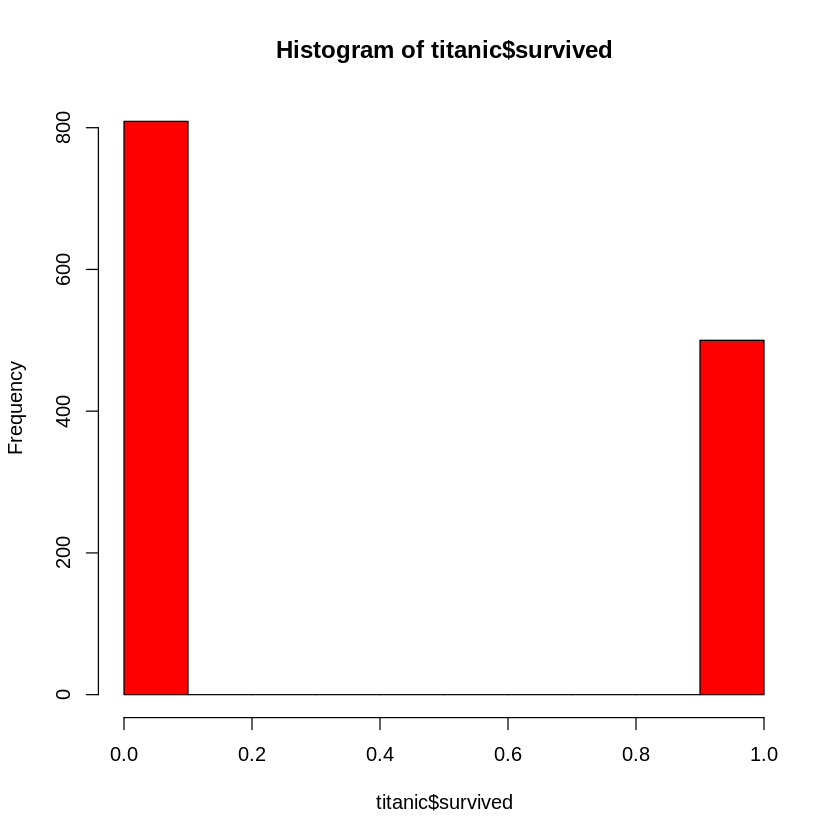

In [28]:
hist(titanic$survived, col="red")

In [29]:
#titanic$sex = ifelse(titanic$sex == 'male', 1, 0)
#titanic$age = as.numeric(titanic$age)
unique(titanic$fare_ordinal)
titanic$fare_ordinal = as.factor(titanic$fare_ordinal)
titanic$survived = as.factor(titanic$survived)

[1] "most expensive" "more expensive" "normal"

In [30]:
titanic$dAge = cut(titanic$age, breaks=c(0,18,100), labels=c("child","adult"))

In [31]:
#titanic$fare = (titanic$fare - min(titanic$fare))/(max(titanic$fare) - min(titanic$fare))
#titanic$age = (titanic$age - min(titanic$age))/(max(titanic$age) - min(titanic$age))

In [32]:
ind = sample(2, nrow(titanic), replace = TRUE, prob = c(0.8, 0.2))
train.data = titanic[ind==1, ]
test.data = titanic[ind==2, ]

In [33]:
head(titanic, 1)

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family,has_family,fare_ordinal,title,title_short,age_ordinal,deck,dAge
,<int>,<fct>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<fct>
1,1,1,female,29,0,0,24160,211.3375,B5,Southampton,0,False,most expensive,Miss,Miss,adult,B,adult


In [34]:
model = rpart(survived ~ pclass + sex + dAge + fare, data = train.data)

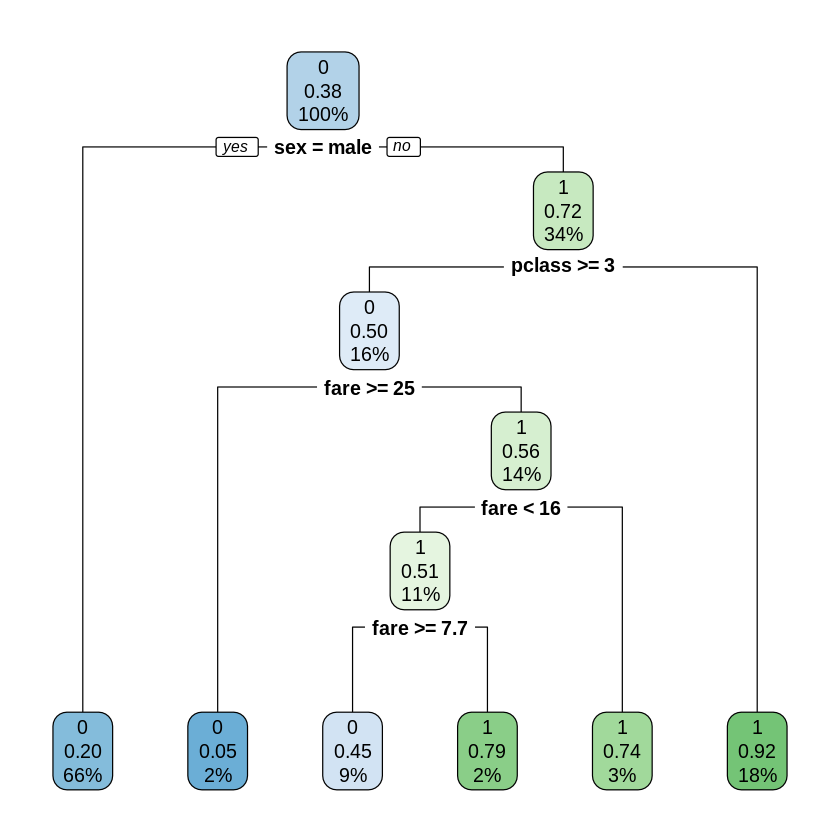

In [35]:
library(rpart.plot)
rpart.plot(model)

In [36]:
y_pred = predict(model, test.data, type = 'class')

In [37]:
tbl = table(predicted = y_pred, actual = test.data$survived)

In [38]:
library(caret)
confusionMatrix(tbl)

Confusion Matrix and Statistics

         actual
predicted   0   1
        0 147  42
        1   9  63
                                          
               Accuracy : 0.8046          
                 95% CI : (0.7512, 0.8509)
    No Information Rate : 0.5977          
    P-Value [Acc > NIR] : 7.385e-13       
                                          
                  Kappa : 0.5717          
                                          
 Mcnemar's Test P-Value : 7.433e-06       
                                          
            Sensitivity : 0.9423          
            Specificity : 0.6000          
         Pos Pred Value : 0.7778          
         Neg Pred Value : 0.8750          
             Prevalence : 0.5977          
         Detection Rate : 0.5632          
   Detection Prevalence : 0.7241          
      Balanced Accuracy : 0.7712          
                                          
       'Positive' Class : 0               
                                     